# Práctica de Clasificación: Nivel de Pobreza

**Dataset:** Beneficiarios del Centro Integral de Atención al Adulto Mayor - Distrito de La Arena

**Variable Objetivo:** `NIVEL_POBREZA` (Clasificación multiclase)

**Categorías:**
- EXTREMA POBREZA
- POBREZA
- NO POBRE
- NO AFILIADO

**Metodología:**
- Clasificador binario por cada clase (One-vs-Rest)
- Accuracy ponderada como métrica final

---

## 0. Importación de Librerías

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

# Modelos de clasificación
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Librerias importadas correctamente')

Librerias importadas correctamente


## 1. Preparación de Datos

### 1.1 Carga del Dataset

In [2]:
# Cargar el dataset con codificación latin-1 (caracteres especiales en español)
df = pd.read_csv('Dataset_Beneficiarios_Centro_Integral_Atención_Adulto_Mayor_La_Arena_4.csv', 
                 encoding='latin-1')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nColumnas del dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Dimensiones del dataset: 3128 filas x 32 columnas

Columnas del dataset:
   1. ITEM
   2. FECHA_CORTE
   3. DEPARTAMENTO
   4. PROVINCIA
   5. DISTRITO
   6. GOBIERNO_LOCAL
   7. UBIGEO
   8. DNI
   9. APELLIDOS_NOMBRES
  10. SEXO
  11. AÑO_NACIMIENTO
  12. EDAD
  13. ESTADO_CIVIL
  14. NUMERO_HIJOS
  15. DIRECCION
  16. FECHA_INSCRIPCION
  17. LEE_Y_ESCRIBE
  18. NIVEL_ESTUDIO
  19. TENENCIA_VIVIENDA
  20. TIPO_VIVIENDA
  21. SEGURO_SALUD
  22. PENSION_ESTADO
  23. PENSION65
  24. ONP
  25. PENSION_POLICIAL
  26. SISFOH
  27. NIVEL_POBREZA
  28. TRABAJA
  29. PROBLEMA_SALUD
  30. PROBLEMA_SALUD_MALESTAR
  31. RECIBE_TRATAMIENTO
  32. CONADIS


In [3]:
# Exploración inicial
df.head()

,ITEM,FECHA_CORTE,DEPARTAMENTO,PROVINCIA,DISTRITO,GOBIERNO_LOCAL,UBIGEO,DNI,APELLIDOS_NOMBRES,SEXO,...,PENSION65,ONP,PENSION_POLICIAL,SISFOH,NIVEL_POBREZA,TRABAJA,PROBLEMA_SALUD,PROBLEMA_SALUD_MALESTAR,RECIBE_TRATAMIENTO,CONADIS
0,1,20250523,PIURA,PIURA,LA ARENA,MUNICIPALIDAD DISTRITAL DE LA ARENA,200109.0,8KRD7CSLVL,AD2cA3YVPpxIHoRkThUfl4wvUg3,FEMENINO,...,NO,NO,NO,SI,EXTREMA POBREZA,NO,NO,NO TIENE,NO,NO
1,2,20250523,PIURA,PIURA,LA ARENA,MUNICIPALIDAD DISTRITAL DE LA ARENA,200109.0,DSOYZ71SCY,ADk2BJ7IQmTLHUnCVih78u0gDZe,FEMENINO,...,NO,NO,NO,SI,POBREZA,NO,SI,PRESION ARTERIAL PARALISIS DIABETES,SI,NO
2,3,20250523,PIURA,PIURA,LA ARENA,MUNICIPALIDAD DISTRITAL DE LA ARENA,200109.0,RJAVVS25FF,ALGpsQyHA18BXyKeCxaOczzzdkVN,FEMENINO,...,NO,NO,NO,SI,EXTREMA POBREZA,NO,SI,ARTRITIS,NO,NO
3,4,20250523,PIURA,PIURA,LA ARENA,MUNICIPALIDAD DISTRITAL DE LA ARENA,200109.0,KTYE9Z3G4S,ALa2PYzxTB0YyzpajPoDJVG,FEMENINO,...,NO,NO,NO,SI,EXTREMA POBREZA,NO,SI,PRESION ARTERIAL,SI,NO
4,5,20250523,PIURA,PIURA,LA ARENA,MUNICIPALIDAD DISTRITAL DE LA ARENA,200109.0,W1HJAOEMZ7,AN00bdw24iZrp7aMvG4Nhjc,FEMENINO,...,NO,NO,NO,SI,EXTREMA POBREZA,NO,SI,PRESION ARTERIAL,SI,NO


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3128 entries, 0 to 3127
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ITEM                     3103 non-null   str    
 1   FECHA_CORTE              3104 non-null   str    
 2   DEPARTAMENTO             3104 non-null   str    
 3   PROVINCIA                3103 non-null   str    
 4   DISTRITO                 3103 non-null   str    
 5   GOBIERNO_LOCAL           3103 non-null   str    
 6   UBIGEO                   3102 non-null   float64
 7   DNI                      3102 non-null   str    
 8   APELLIDOS_NOMBRES        3102 non-null   str    
 9   SEXO                     3102 non-null   str    
 10  AÑO_NACIMIENTO           3102 non-null   float64
 11  EDAD                     3102 non-null   float64
 12  ESTADO_CIVIL             3102 non-null   str    
 13  NUMERO_HIJOS             3102 non-null   str    
 14  DIRECCION                3102 non-n

In [5]:
# Distribución de la variable objetivo
print('Distribucion de NIVEL_POBREZA:')
print(df['NIVEL_POBREZA'].value_counts())
print(f'\nPorcentaje:')
print(df['NIVEL_POBREZA'].value_counts(normalize=True).round(4) * 100)

Distribucion de NIVEL_POBREZA:
NIVEL_POBREZA
NO AFILIADO        1735
EXTREMA POBREZA    1069
POBREZA             241
NO POBRE             57
Name: count, dtype: int64

Porcentaje:
NIVEL_POBREZA
NO AFILIADO        55.93
EXTREMA POBREZA    34.46
POBREZA             7.77
NO POBRE            1.84
Name: proportion, dtype: float64


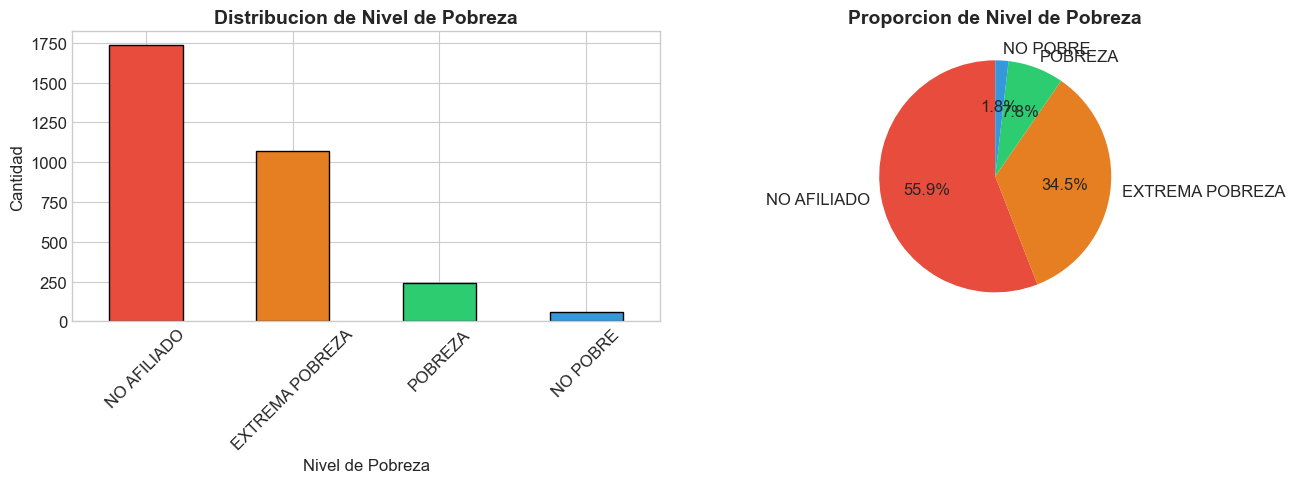

In [6]:
# Visualización de la distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']
df['NIVEL_POBREZA'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribucion de Nivel de Pobreza', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nivel de Pobreza')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de torta
df['NIVEL_POBREZA'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                         colors=colors, startangle=90)
axes[1].set_title('Proporcion de Nivel de Pobreza', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 1.2 Tratamiento de Campos Vacíos (Valores Nulos)

In [7]:
# Análisis de valores nulos
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

tabla_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': nulos_pct
})

print('Resumen de valores nulos:')
print(tabla_nulos[tabla_nulos['Valores Nulos'] > 0])

Resumen de valores nulos:
                         Valores Nulos  Porcentaje (%)
ITEM                                25            0.80
FECHA_CORTE                         24            0.77
DEPARTAMENTO                        24            0.77
PROVINCIA                           25            0.80
DISTRITO                            25            0.80
GOBIERNO_LOCAL                      25            0.80
UBIGEO                              26            0.83
DNI                                 26            0.83
APELLIDOS_NOMBRES                   26            0.83
SEXO                                26            0.83
AÑO_NACIMIENTO                      26            0.83
EDAD                                26            0.83
ESTADO_CIVIL                        26            0.83
NUMERO_HIJOS                        26            0.83
DIRECCION                           26            0.83
FECHA_INSCRIPCION                   26            0.83
LEE_Y_ESCRIBE                       26 

In [8]:
# Análisis de valores vacíos (cadenas vacías o espacios en blanco)
print('Valores vacios (cadenas vacias o espacios) por columna:')
for col in df.columns:
    if df[col].dtype == 'object':
        vacios = (df[col].str.strip() == '').sum()
        if vacios > 0:
            print(f'  {col}: {vacios} valores vacios')

Valores vacios (cadenas vacias o espacios) por columna:


In [9]:
# Eliminar filas con valores nulos (son pocas, ~26 de 3128 = 0.83%)
print(f'Filas antes de eliminar nulos: {len(df)}')
df = df.dropna()
print(f'Filas despues de eliminar nulos: {len(df)}')
print(f'Filas eliminadas: {3128 - len(df)}')

# Reemplazar cadenas vacías por valores más descriptivos en columnas con vacíos
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()
        df.loc[df[col] == '', col] = 'NO ESPECIFICADO'

print('\nValores nulos restantes:', df.isnull().sum().sum())

Filas antes de eliminar nulos: 3128
Filas despues de eliminar nulos: 3100
Filas eliminadas: 28

Valores nulos restantes: 0


### 1.3 Tratamiento de Campos Alfanuméricos

In [10]:
# Identificar columnas que NO son útiles para la clasificación
# (datos identificativos, constantes o alfanuméricos sin valor predictivo)

print('Columnas a eliminar y razon:')
columnas_eliminar = {
    'ITEM': 'Identificador secuencial, no tiene valor predictivo',
    'FECHA_CORTE': 'Fecha constante para todos los registros',
    'DEPARTAMENTO': 'Valor constante: PIURA',
    'PROVINCIA': 'Valor constante: PIURA', 
    'DISTRITO': 'Valor constante: LA ARENA',
    'GOBIERNO_LOCAL': 'Valor constante: MUNICIPALIDAD DISTRITAL DE LA ARENA',
    'UBIGEO': 'Valor constante: 200109',
    'DNI': 'Dato anonimizado, identificador unico sin valor predictivo',
    'APELLIDOS_NOMBRES': 'Dato anonimizado, identificador unico sin valor predictivo',
    'FECHA_INSCRIPCION': 'Fecha de inscripcion, no relevante para nivel de pobreza',
    'DIRECCION': 'Alta cardinalidad (105 valores unicos), texto libre',
    'PROBLEMA_SALUD_MALESTAR': 'Alta cardinalidad (119 valores unicos), texto libre descriptivo',
    'PENSION65': 'Valor constante: NO (todos)',
    'PENSION_POLICIAL': 'Valor constante: NO (todos)',
    'CONADIS': 'Valor casi constante: NO (todos)'
}

for col, razon in columnas_eliminar.items():
    print(f'  - {col}: {razon}')

# Eliminar columnas
df = df.drop(columns=list(columnas_eliminar.keys()))
print(f'\nColumnas restantes ({len(df.columns)}): {list(df.columns)}')

Columnas a eliminar y razon:
  - ITEM: Identificador secuencial, no tiene valor predictivo
  - FECHA_CORTE: Fecha constante para todos los registros
  - DEPARTAMENTO: Valor constante: PIURA
  - PROVINCIA: Valor constante: PIURA
  - DISTRITO: Valor constante: LA ARENA
  - GOBIERNO_LOCAL: Valor constante: MUNICIPALIDAD DISTRITAL DE LA ARENA
  - UBIGEO: Valor constante: 200109
  - DNI: Dato anonimizado, identificador unico sin valor predictivo
  - APELLIDOS_NOMBRES: Dato anonimizado, identificador unico sin valor predictivo
  - FECHA_INSCRIPCION: Fecha de inscripcion, no relevante para nivel de pobreza
  - DIRECCION: Alta cardinalidad (105 valores unicos), texto libre
  - PROBLEMA_SALUD_MALESTAR: Alta cardinalidad (119 valores unicos), texto libre descriptivo
  - PENSION65: Valor constante: NO (todos)
  - PENSION_POLICIAL: Valor constante: NO (todos)
  - CONADIS: Valor casi constante: NO (todos)

Columnas restantes (17): ['SEXO', 'AÑO_NACIMIENTO', 'EDAD', 'ESTADO_CIVIL', 'NUMERO_HIJOS', '

### 1.4 Tratamiento de Campos Categóricos

In [11]:
# Revisar las columnas categóricas restantes
print('Columnas categoricas y sus valores unicos:\n')
for col in df.select_dtypes(include='object').columns:
    if col != 'NIVEL_POBREZA':  # excluir la variable objetivo
        print(f'{col} ({df[col].nunique()} valores):')
        print(f'  {df[col].unique()}')
        print()

Columnas categoricas y sus valores unicos:

SEXO (2 valores):
  <StringArray>
['FEMENINO', 'MASCULINO']
Length: 2, dtype: str

ESTADO_CIVIL (9 valores):
  <StringArray>
[    'SOLTERA',       'VIUDA',      'CASADA',     'SOLTERO', 'CONVIVIENTE',
      'CASADO',       'VIUDO',  'DIVORCIADA',  'DIVORCIADO']
Length: 9, dtype: str

NUMERO_HIJOS (19 valores):
  <StringArray>
[ '9',  '7',  '2',  '0',  '4',  '6', '19',  ' ',  '5',  '3',  '8', '13', '15',
 '11',  '1', '10', '12', '14', '17']
Length: 19, dtype: str

LEE_Y_ESCRIBE (2 valores):
  <StringArray>
['SI', 'NO']
Length: 2, dtype: str

NIVEL_ESTUDIO (9 valores):
  <StringArray>
[                 'Primaria incompleta',
                      'Sin instruccion',
                    'Primaria completa',
                  'Secundaria completa',
                'Secundaria incompleta',
   'Superior No Universitaria completa',
      'Superior Universitaria Completa',
    'Superior Universitaria Incompleta',
 'Superior No Universitaria Incompleta

In [12]:
# Normalización de ESTADO_CIVIL: unificar géneros (CASADO/CASADA -> CASADO, etc.)
mapeo_estado_civil = {
    'CASADO': 'CASADO',
    'CASADA': 'CASADO',
    'SOLTERA': 'SOLTERO',
    'SOLTERO': 'SOLTERO',
    'VIUDA': 'VIUDO',
    'VIUDO': 'VIUDO',
    'DIVORCIADA': 'DIVORCIADO',
    'DIVORCIADO': 'DIVORCIADO',
    'CONVIVIENTE': 'CONVIVIENTE'
}
df['ESTADO_CIVIL'] = df['ESTADO_CIVIL'].map(mapeo_estado_civil)

print('ESTADO_CIVIL despues de normalizar:')
print(df['ESTADO_CIVIL'].value_counts())

ESTADO_CIVIL despues de normalizar:
ESTADO_CIVIL
CASADO         2130
SOLTERO         549
VIUDO           332
CONVIVIENTE      58
DIVORCIADO       31
Name: count, dtype: int64


In [13]:
# Convertir NUMERO_HIJOS a numérico
df['NUMERO_HIJOS'] = pd.to_numeric(df['NUMERO_HIJOS'], errors='coerce')
# Rellenar los valores faltantes con la mediana
mediana_hijos = df['NUMERO_HIJOS'].median()
df['NUMERO_HIJOS'] = df['NUMERO_HIJOS'].fillna(mediana_hijos).astype(int)

print(f'NUMERO_HIJOS - Mediana usada para imputacion: {mediana_hijos}')
print(df['NUMERO_HIJOS'].describe())

NUMERO_HIJOS - Mediana usada para imputacion: 6.0
count    3100.000000
mean        5.857742
std         2.708505
min         0.000000
25%         4.000000
50%         6.000000
75%         7.000000
max        19.000000
Name: NUMERO_HIJOS, dtype: float64


In [14]:
# Codificación de variables categóricas con LabelEncoder
# Guardar los encoders para referencia
label_encoders = {}
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()
columnas_categoricas.remove('NIVEL_POBREZA')  # No codificar la variable objetivo aun

print('Codificacion de variables categoricas:\n')
for col in columnas_categoricas:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f'{col}:')
    for i, clase in enumerate(le.classes_):
        print(f'  {clase} -> {i}')
    print()

Codificacion de variables categoricas:

SEXO:
  FEMENINO -> 0
  MASCULINO -> 1

ESTADO_CIVIL:
  CASADO -> 0
  CONVIVIENTE -> 1
  DIVORCIADO -> 2
  SOLTERO -> 3
  VIUDO -> 4

LEE_Y_ESCRIBE:
  NO -> 0
  SI -> 1

NIVEL_ESTUDIO:
  Primaria completa -> 0
  Primaria incompleta -> 1
  Secundaria completa -> 2
  Secundaria incompleta -> 3
  Sin instruccion -> 4
  Superior No Universitaria Incompleta -> 5
  Superior No Universitaria completa -> 6
  Superior Universitaria Completa -> 7
  Superior Universitaria Incompleta -> 8

TENENCIA_VIVIENDA:
    -> 0
  Alquilada -> 1
  Otros -> 2
  Propia -> 3

TIPO_VIVIENDA:
    -> 0
  Casa Independiente -> 1
  Casa de material noble -> 2
  Choza o cabaña -> 3
  Departamento en edificio -> 4
  Otros -> 5
  Vivienda en casa de vecindad ( callejOn solar o corralOn ) -> 6
  Vivienda en quinta -> 7
  Vivienda improvisada -> 8

SEGURO_SALUD:
    -> 0
  ESSALUD -> 1
  NINGUNO -> 2
  PRIVADO -> 3
  SIS -> 4

PENSION_ESTADO:
  NO -> 0
  SI -> 1

ONP:
  NO -> 0
  SI

### 1.5 Selección de Datos (Features)

In [15]:
# Definir las variables predictoras (X) y guardar la variable objetivo original
features = [col for col in df.columns if col != 'NIVEL_POBREZA']

X = df[features]
y_original = df['NIVEL_POBREZA']  # Variable objetivo en texto

# Obtener las clases únicas
clases = sorted(y_original.unique())

print(f'Variables predictoras ({len(features)}):')
for f in features:
    print(f'  - {f}')

print(f'\nDimensiones de X: {X.shape}')
print(f'\nClases de la variable objetivo ({len(clases)}):')
for c in clases:
    n = (y_original == c).sum()
    print(f'  - {c}: {n} muestras ({n/len(y_original)*100:.1f}%)')

Variables predictoras (16):
  - SEXO
  - AÑO_NACIMIENTO
  - EDAD
  - ESTADO_CIVIL
  - NUMERO_HIJOS
  - LEE_Y_ESCRIBE
  - NIVEL_ESTUDIO
  - TENENCIA_VIVIENDA
  - TIPO_VIVIENDA
  - SEGURO_SALUD
  - PENSION_ESTADO
  - ONP
  - SISFOH
  - TRABAJA
  - PROBLEMA_SALUD
  - RECIBE_TRATAMIENTO

Dimensiones de X: (3100, 16)

Clases de la variable objetivo (4):
  - EXTREMA POBREZA: 1068 muestras (34.5%)
  - NO AFILIADO: 1734 muestras (55.9%)
  - NO POBRE: 57 muestras (1.8%)
  - POBREZA: 241 muestras (7.8%)


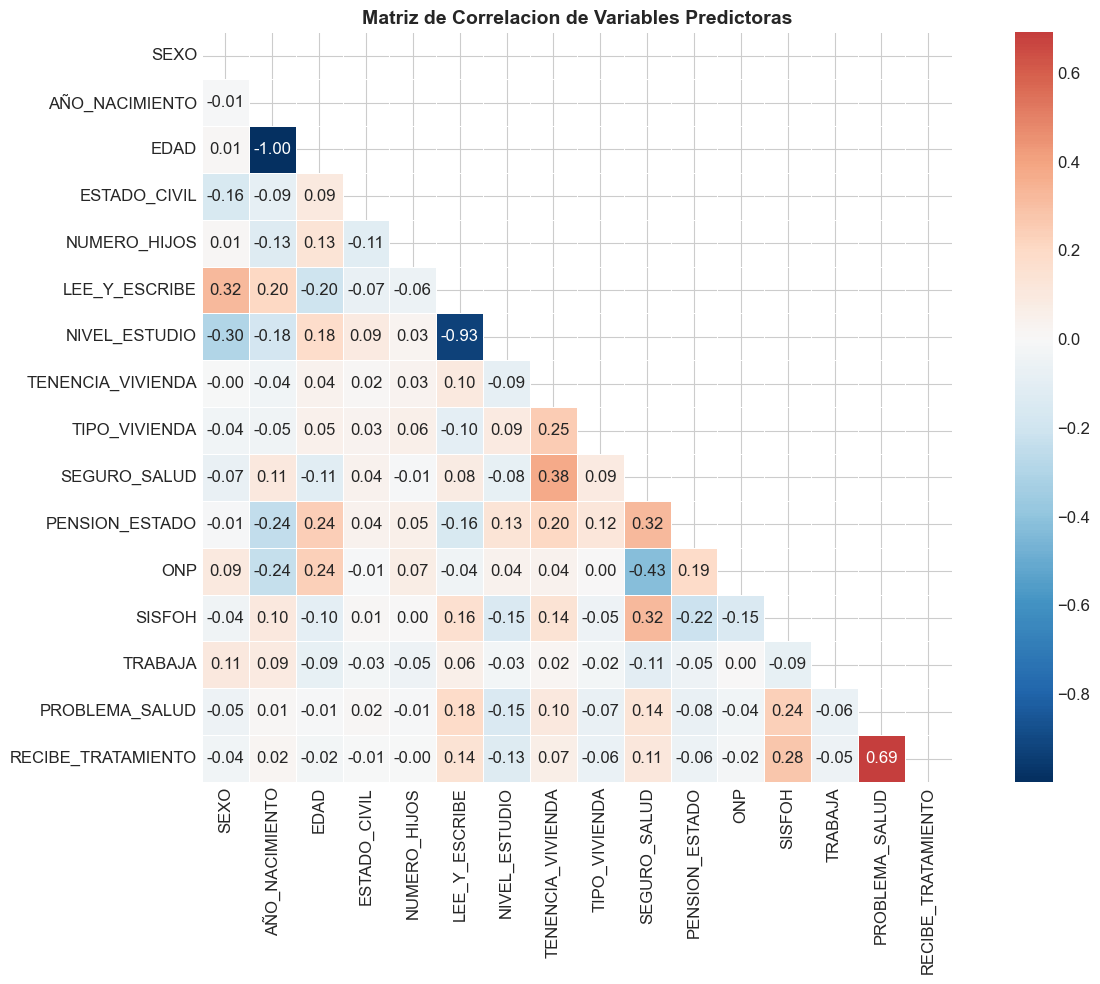

In [16]:
# Análisis de correlación entre las features
plt.figure(figsize=(14, 10))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True)
plt.title('Matriz de Correlacion de Variables Predictoras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Escalado de características
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

print('Datos escalados (primeras 5 filas):')
X_scaled.head()

Datos escalados (primeras 5 filas):


,SEXO,AÑO_NACIMIENTO,EDAD,ESTADO_CIVIL,NUMERO_HIJOS,LEE_Y_ESCRIBE,NIVEL_ESTUDIO,TENENCIA_VIVIENDA,TIPO_VIVIENDA,SEGURO_SALUD,PENSION_ESTADO,ONP,SISFOH,TRABAJA,PROBLEMA_SALUD,RECIBE_TRATAMIENTO
0,-0.914005,1.347209,-1.256302,1.300365,1.160332,1.649693,-1.578065,0.179086,-0.215864,0.433859,-1.320365,-0.246814,1.124467,-0.198924,-0.648625,-0.455670
1,-0.914005,-0.311490,0.276075,1.950024,1.160332,-0.606173,0.563480,0.179086,-0.215864,-1.697619,-1.320365,-0.246814,1.124467,-0.198924,1.541722,2.194569
2,-0.914005,1.347209,-1.384000,-0.648611,0.421798,-0.606173,0.563480,0.179086,-0.215864,0.433859,-1.320365,-0.246814,1.124467,-0.198924,1.541722,-0.455670
3,-0.914005,1.347209,-1.384000,1.950024,-1.424536,-0.606173,0.563480,0.179086,-0.215864,0.433859,-1.320365,-0.246814,1.124467,-0.198924,1.541722,2.194569
4,-0.914005,1.474801,-1.511698,-0.648611,0.421798,-0.606173,0.563480,0.179086,-0.215864,0.433859,-1.320365,-0.246814,1.124467,-0.198924,1.541722,2.194569


---

## 2. Preparación del Entrenamiento

### 2.1 División Train/Test

In [18]:
# División estratificada 80/20
X_train, X_test, y_train_orig, y_test_orig = train_test_split(
    X_scaled, y_original, test_size=0.2, random_state=42, stratify=y_original
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras')
print(f'\nDistribucion en entrenamiento:')
for c in clases:
    count = (y_train_orig == c).sum()
    print(f'  {c}: {count} ({count/len(y_train_orig)*100:.1f}%)')
print(f'\nDistribucion en prueba:')
for c in clases:
    count = (y_test_orig == c).sum()
    print(f'  {c}: {count} ({count/len(y_test_orig)*100:.1f}%)')

Conjunto de entrenamiento: 2480 muestras
Conjunto de prueba: 620 muestras

Distribucion en entrenamiento:
  EXTREMA POBREZA: 854 (34.4%)
  NO AFILIADO: 1387 (55.9%)
  NO POBRE: 46 (1.9%)
  POBREZA: 193 (7.8%)

Distribucion en prueba:
  EXTREMA POBREZA: 214 (34.5%)
  NO AFILIADO: 347 (56.0%)
  NO POBRE: 11 (1.8%)
  POBREZA: 48 (7.7%)


### 2.2 Creación de Targets Binarios (One-vs-Rest)

Se crea una variable objetivo binaria para cada clase:
- **1** = La muestra pertenece a la clase
- **0** = La muestra NO pertenece a la clase (pertenece al "resto")

Esto permite entrenar un **clasificador binario independiente por cada clase**.

In [19]:
# Crear targets binarios para cada clase (One-vs-Rest)
targets_binarios_train = {}
targets_binarios_test = {}

print('Targets binarios creados (One-vs-Rest):\n')
for clase in clases:
    # 1 si pertenece a la clase, 0 si pertenece al "resto"
    targets_binarios_train[clase] = (y_train_orig == clase).astype(int)
    targets_binarios_test[clase] = (y_test_orig == clase).astype(int)
    
    n_pos_train = targets_binarios_train[clase].sum()
    n_neg_train = len(targets_binarios_train[clase]) - n_pos_train
    n_pos_test = targets_binarios_test[clase].sum()
    n_neg_test = len(targets_binarios_test[clase]) - n_pos_test
    
    print(f'Clase: "{clase}"')
    print(f'  Train -> Positivos (1): {n_pos_train} | Negativos (0): {n_neg_train}')
    print(f'  Test  -> Positivos (1): {n_pos_test} | Negativos (0): {n_neg_test}')
    print()

Targets binarios creados (One-vs-Rest):

Clase: "EXTREMA POBREZA"
  Train -> Positivos (1): 854 | Negativos (0): 1626
  Test  -> Positivos (1): 214 | Negativos (0): 406

Clase: "NO AFILIADO"
  Train -> Positivos (1): 1387 | Negativos (0): 1093
  Test  -> Positivos (1): 347 | Negativos (0): 273

Clase: "NO POBRE"
  Train -> Positivos (1): 46 | Negativos (0): 2434
  Test  -> Positivos (1): 11 | Negativos (0): 609

Clase: "POBREZA"
  Train -> Positivos (1): 193 | Negativos (0): 2287
  Test  -> Positivos (1): 48 | Negativos (0): 572



### 2.3 Cross Validation

In [20]:
# Configurar Cross Validation estratificado con 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Configuracion de Cross Validation:')
print(f'  - Tipo: StratifiedKFold (mantiene la proporcion de clases en cada fold)')
print(f'  - Numero de folds: 5')
print(f'  - Shuffle: Si')
print(f'  - Random state: 42')

Configuracion de Cross Validation:
  - Tipo: StratifiedKFold (mantiene la proporcion de clases en cada fold)
  - Numero de folds: 5
  - Shuffle: Si
  - Random state: 42


### 2.4 Inicializar Modelos de Clasificación Binaria

Se definen los modelos que se usarán como clasificadores binarios para cada clase.

In [21]:
# Definir los modelos a evaluar como clasificadores binarios
def crear_modelos():
    return {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }

print('Modelos disponibles para clasificacion binaria:')
for nombre in crear_modelos():
    print(f'  - {nombre}')

Modelos disponibles para clasificacion binaria:
  - Random Forest
  - Gradient Boosting
  - SVM
  - KNN


In [22]:
# Evaluación inicial con Cross Validation para cada modelo y cada clase
print('Evaluacion inicial con Cross Validation (5-Fold) - Clasificador binario por clase\n')

resultados_cv_inicial = {}

for nombre_modelo in crear_modelos():
    print(f'\n{"="*60}')
    print(f'Modelo: {nombre_modelo}')
    print(f'{"="*60}')
    resultados_cv_inicial[nombre_modelo] = {}
    
    for clase in clases:
        modelo = crear_modelos()[nombre_modelo]
        y_bin = targets_binarios_train[clase]
        scores = cross_val_score(modelo, X_train, y_bin, cv=cv, scoring='accuracy')
        resultados_cv_inicial[nombre_modelo][clase] = scores
        print(f'  {clase:<25} Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}')

Evaluacion inicial con Cross Validation (5-Fold) - Clasificador binario por clase


Modelo: Random Forest
  EXTREMA POBREZA           Accuracy: 0.8879 +/- 0.0077
  NO AFILIADO               Accuracy: 0.9988 +/- 0.0016
  NO POBRE                  Accuracy: 0.9790 +/- 0.0010
  POBREZA                   Accuracy: 0.9065 +/- 0.0065

Modelo: Gradient Boosting
  EXTREMA POBREZA           Accuracy: 0.9048 +/- 0.0067
  NO AFILIADO               Accuracy: 0.9988 +/- 0.0016
  NO POBRE                  Accuracy: 0.9798 +/- 0.0026
  POBREZA                   Accuracy: 0.9226 +/- 0.0042

Modelo: SVM
  EXTREMA POBREZA           Accuracy: 0.8992 +/- 0.0075
  NO AFILIADO               Accuracy: 0.9984 +/- 0.0024
  NO POBRE                  Accuracy: 0.9815 +/- 0.0008
  POBREZA                   Accuracy: 0.9226 +/- 0.0010

Modelo: KNN
  EXTREMA POBREZA           Accuracy: 0.8718 +/- 0.0065
  NO AFILIADO               Accuracy: 0.9790 +/- 0.0068
  NO POBRE                  Accuracy: 0.9810 +/- 0.0010
 

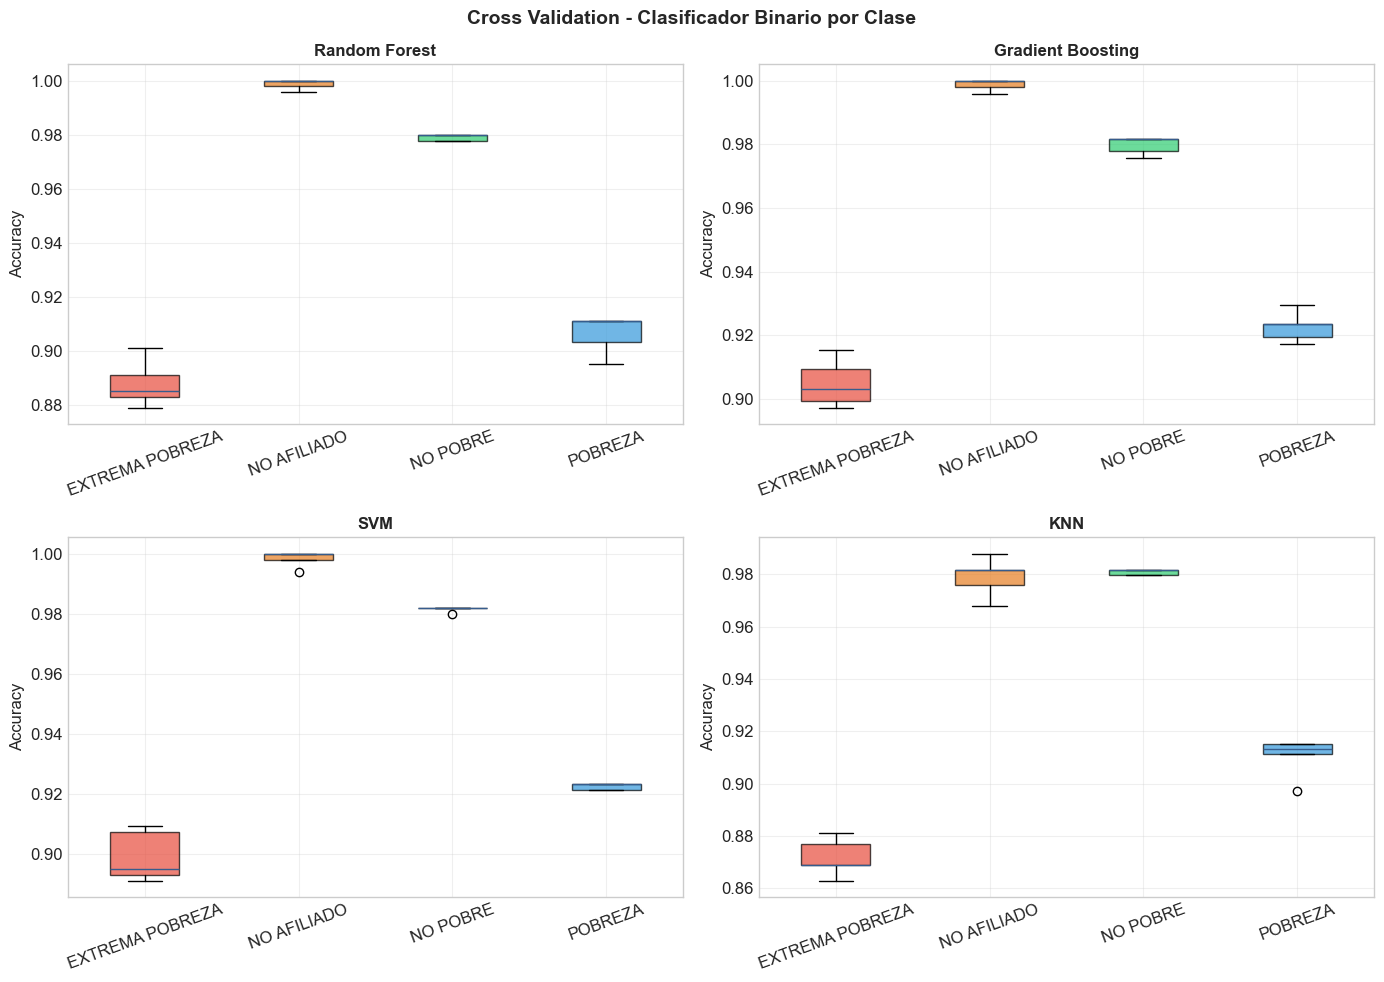

In [23]:
# Visualización de resultados de CV por modelo y clase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
colors_box = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

for idx, nombre_modelo in enumerate(crear_modelos()):
    data = [resultados_cv_inicial[nombre_modelo][c] for c in clases]
    bp = axes[idx].boxplot(data, labels=[c[:15] for c in clases], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[idx].set_title(f'{nombre_modelo}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=20)

plt.suptitle('Cross Validation - Clasificador Binario por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. Entrenamiento con Diferentes Parámetros

### 3.1 Optimización de Hiperparámetros con GridSearchCV

Para cada clase, se entrena un **clasificador binario optimizado** usando GridSearchCV.
Se prueban múltiples modelos con distintos hiperparámetros.

In [24]:
# Definir grids de hiperparámetros para cada tipo de modelo
configuraciones_modelos = {
    'Random Forest': {
        'modelo': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, 30, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'Gradient Boosting': {
        'modelo': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    },
    'SVM': {
        'modelo': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'poly'],
            'gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'modelo': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']
        }
    }
}

print('Configuraciones de hiperparametros definidas para:')
for nombre, config in configuraciones_modelos.items():
    n_combinaciones = 1
    for v in config['params'].values():
        n_combinaciones *= len(v)
    print(f'  - {nombre}: {n_combinaciones} combinaciones')

Configuraciones de hiperparametros definidas para:
  - Random Forest: 108 combinaciones
  - Gradient Boosting: 72 combinaciones
  - SVM: 16 combinaciones
  - KNN: 36 combinaciones


In [25]:
# ============================================================
# ENTRENAMIENTO: Clasificador binario por cada clase
# Para cada clase se prueba cada modelo con GridSearchCV
# ============================================================

# Almacenar resultados: {clase: {modelo: grid_result}}
resultados_por_clase = {}

for clase in clases:
    print(f'\n{"#"*70}')
    print(f'  CLASE: "{clase}" vs RESTO (Clasificador Binario)')
    print(f'{"#"*70}')
    
    y_bin_train = targets_binarios_train[clase]
    y_bin_test = targets_binarios_test[clase]
    
    resultados_por_clase[clase] = {}
    
    for nombre_modelo, config in configuraciones_modelos.items():
        print(f'\n  --- {nombre_modelo} ---')
        
        grid = GridSearchCV(
            config['modelo'],
            config['params'],
            cv=cv,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_bin_train)
        
        # Predicciones en test
        y_pred = grid.best_estimator_.predict(X_test)
        
        # Métricas
        acc = accuracy_score(y_bin_test, y_pred)
        prec = precision_score(y_bin_test, y_pred, zero_division=0)
        rec = recall_score(y_bin_test, y_pred, zero_division=0)
        f1 = f1_score(y_bin_test, y_pred, zero_division=0)
        
        resultados_por_clase[clase][nombre_modelo] = {
            'grid': grid,
            'best_params': grid.best_params_,
            'best_cv_score': grid.best_score_,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'y_pred': y_pred
        }
        
        print(f'    Mejor CV accuracy: {grid.best_score_:.4f}')
        print(f'    Test accuracy:     {acc:.4f}')
        print(f'    Mejores params:    {grid.best_params_}')


######################################################################
  CLASE: "EXTREMA POBREZA" vs RESTO (Clasificador Binario)
######################################################################

  --- Random Forest ---
    Mejor CV accuracy: 0.9081
    Test accuracy:     0.9065
    Mejores params:    {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

  --- Gradient Boosting ---
    Mejor CV accuracy: 0.9073
    Test accuracy:     0.9048
    Mejores params:    {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}

  --- SVM ---
    Mejor CV accuracy: 0.9020
    Test accuracy:     0.9065
    Mejores params:    {'C': 1, 'gamma': 'auto', 'kernel': 'poly'}

  --- KNN ---
    Mejor CV accuracy: 0.8931
    Test accuracy:     0.8790
    Mejores params:    {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

######################################################################
  CLASE: "NO AFILIADO" vs RES

### 3.2 Métricas por Clase (Clasificador Binario)

In [26]:
# Tabla resumen de métricas por clase y modelo
print('\n' + '='*90)
print('METRICAS DE CADA CLASIFICADOR BINARIO EN CONJUNTO DE PRUEBA')
print('='*90)

for clase in clases:
    print(f'\n--- Clase: "{clase}" vs Resto ---')
    print(f'{"Modelo":<25} {"ACCURACY":<12} {"PRECISION":<12} {"RECALL":<12} {"F1-SCORE":<12}')
    print('-' * 73)
    
    for nombre_modelo in configuraciones_modelos:
        r = resultados_por_clase[clase][nombre_modelo]
        print(f'{nombre_modelo:<25} {r["accuracy"]*100:<12.2f} {r["precision"]*100:<12.2f} {r["recall"]*100:<12.2f} {r["f1"]*100:<12.2f}')


METRICAS DE CADA CLASIFICADOR BINARIO EN CONJUNTO DE PRUEBA

--- Clase: "EXTREMA POBREZA" vs Resto ---
Modelo                    ACCURACY     PRECISION    RECALL       F1-SCORE    
-------------------------------------------------------------------------
Random Forest             90.65        79.10        99.07        87.97       
Gradient Boosting         90.48        78.81        99.07        87.78       
SVM                       90.65        79.32        98.60        87.92       
KNN                       87.90        79.08        88.32        83.44       

--- Clase: "NO AFILIADO" vs Resto ---
Modelo                    ACCURACY     PRECISION    RECALL       F1-SCORE    
-------------------------------------------------------------------------
Random Forest             100.00       100.00       100.00       100.00      
Gradient Boosting         100.00       100.00       100.00       100.00      
SVM                       100.00       100.00       100.00       100.00      
KNN    

In [27]:
# Seleccionar el mejor modelo binario para cada clase
mejor_modelo_por_clase = {}

print('\n' + '='*70)
print('MEJOR MODELO BINARIO POR CADA CLASE')
print('='*70)

for clase in clases:
    mejor_nombre = max(resultados_por_clase[clase], 
                       key=lambda m: resultados_por_clase[clase][m]['accuracy'])
    mejor_r = resultados_por_clase[clase][mejor_nombre]
    mejor_modelo_por_clase[clase] = {
        'nombre': mejor_nombre,
        'resultado': mejor_r
    }
    print(f'\nClase: "{clase}"')
    print(f'  Mejor modelo: {mejor_nombre}')
    print(f'  Accuracy:     {mejor_r["accuracy"]*100:.2f}%')
    print(f'  Precision:    {mejor_r["precision"]*100:.2f}%')
    print(f'  Recall:       {mejor_r["recall"]*100:.2f}%')
    print(f'  F1-Score:     {mejor_r["f1"]*100:.2f}%')
    print(f'  Parametros:   {mejor_r["best_params"]}')


MEJOR MODELO BINARIO POR CADA CLASE

Clase: "EXTREMA POBREZA"
  Mejor modelo: Random Forest
  Accuracy:     90.65%
  Precision:    79.10%
  Recall:       99.07%
  F1-Score:     87.97%
  Parametros:   {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Clase: "NO AFILIADO"
  Mejor modelo: Random Forest
  Accuracy:     100.00%
  Precision:    100.00%
  Recall:       100.00%
  F1-Score:     100.00%
  Parametros:   {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Clase: "NO POBRE"
  Mejor modelo: Random Forest
  Accuracy:     98.23%
  Precision:    0.00%
  Recall:       0.00%
  F1-Score:     0.00%
  Parametros:   {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Clase: "POBREZA"
  Mejor modelo: Gradient Boosting
  Accuracy:     92.42%
  Precision:    100.00%
  Recall:       2.08%
  F1-Score:     4.08%
  Parametros:   {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 

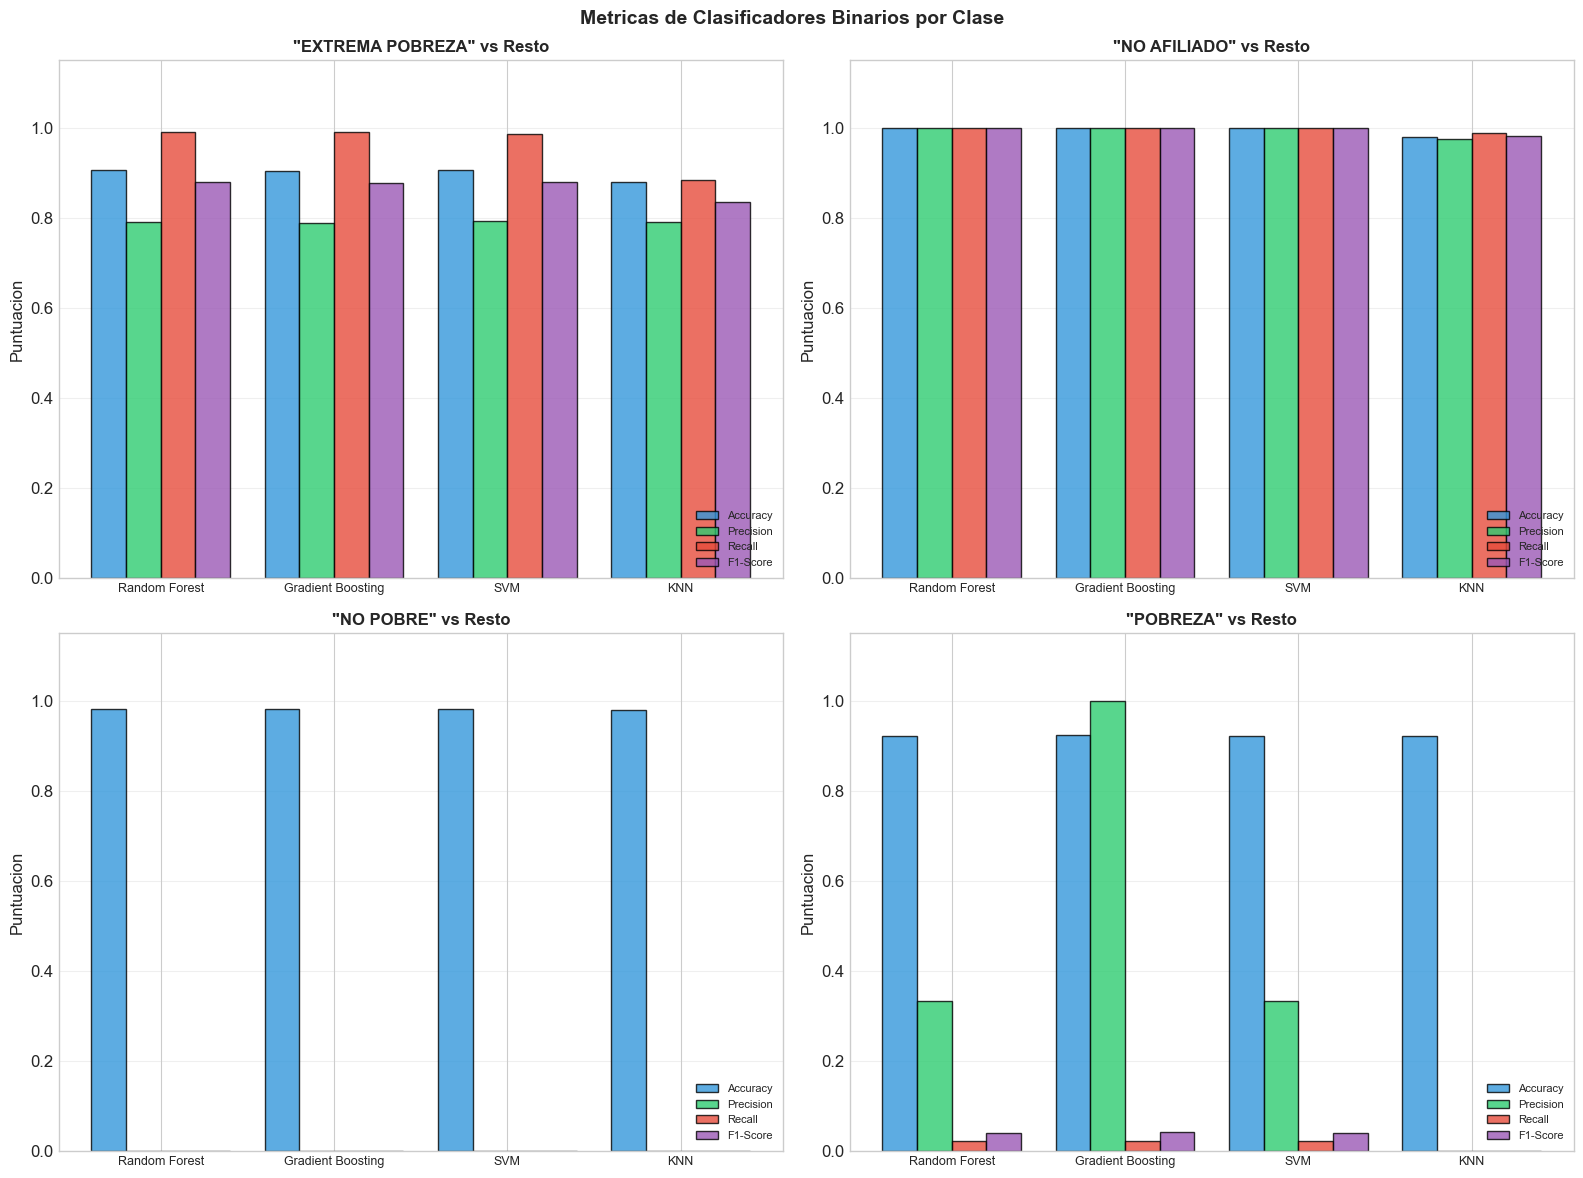

In [28]:
# Visualización: Accuracy de cada clasificador binario por clase
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
colors_modelos = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, clase in enumerate(clases):
    modelos_nombres = list(configuraciones_modelos.keys())
    metricas = ['accuracy', 'precision', 'recall', 'f1']
    metricas_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    x = np.arange(len(modelos_nombres))
    width = 0.2
    
    for i, (met, met_label) in enumerate(zip(metricas, metricas_labels)):
        valores = [resultados_por_clase[clase][m][met] for m in modelos_nombres]
        bars = axes[idx].bar(x + i * width, valores, width, label=met_label, 
                            color=colors_modelos[i], alpha=0.8, edgecolor='black')
    
    axes[idx].set_title(f'"{clase}" vs Resto', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x + width * 1.5)
    axes[idx].set_xticklabels(modelos_nombres, fontsize=9)
    axes[idx].set_ylabel('Puntuacion')
    axes[idx].set_ylim(0, 1.15)
    axes[idx].legend(fontsize=8, loc='lower right')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Metricas de Clasificadores Binarios por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

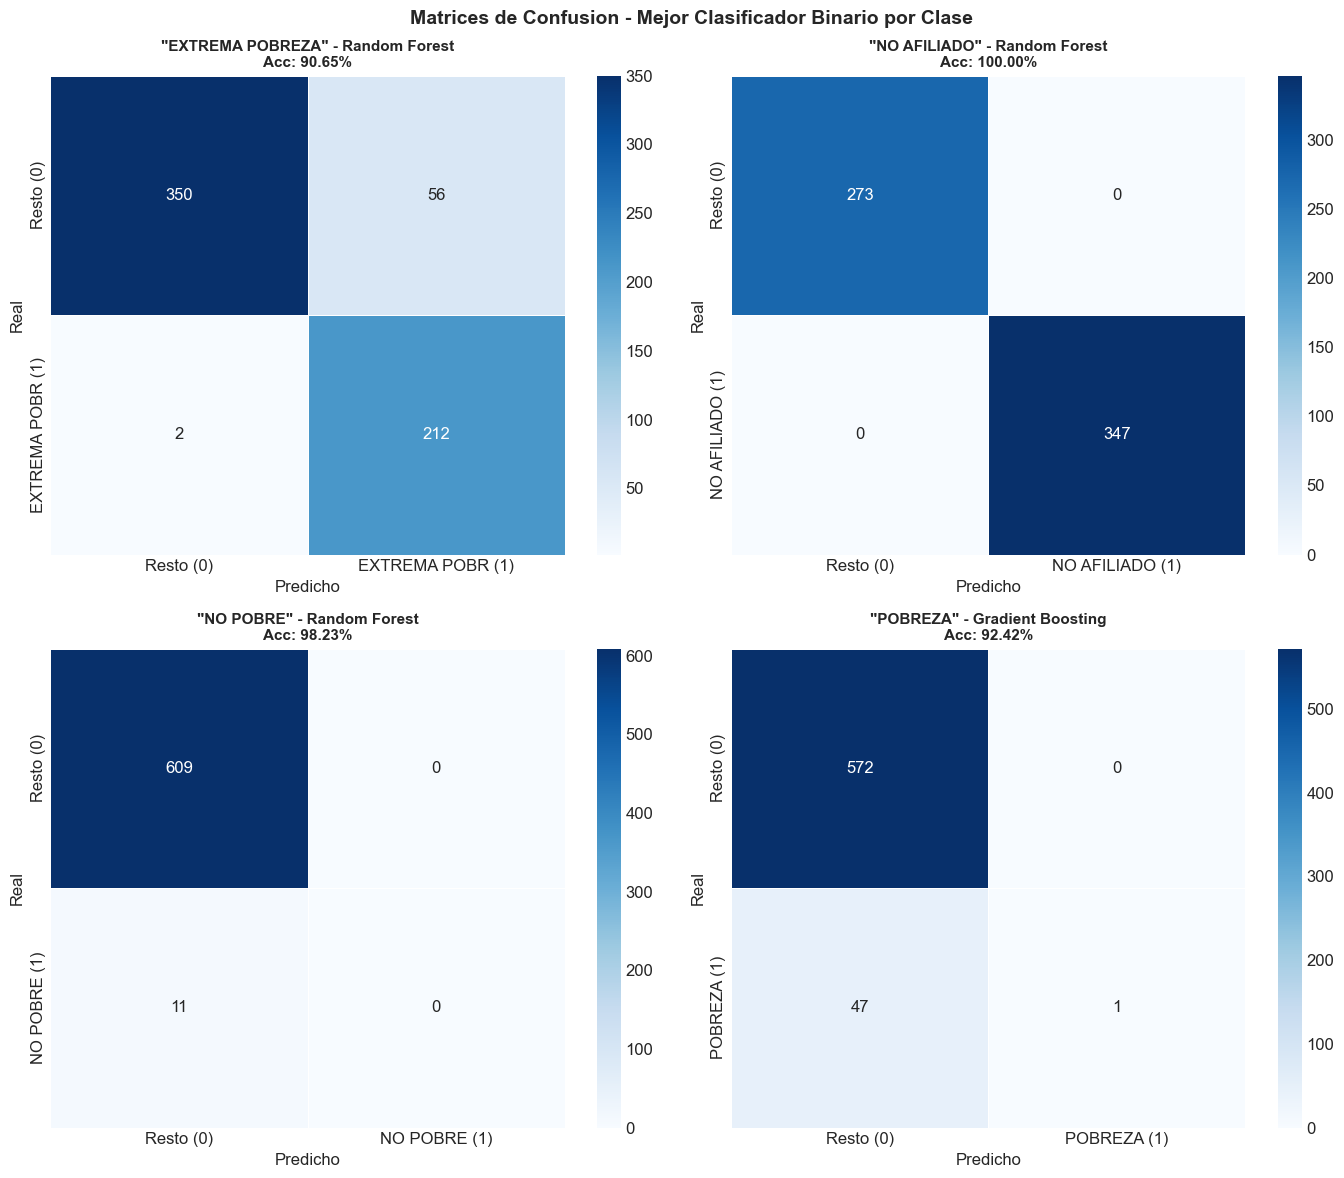

In [29]:
# Matrices de confusión del mejor clasificador binario de cada clase
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, clase in enumerate(clases):
    mejor = mejor_modelo_por_clase[clase]
    y_bin_test = targets_binarios_test[clase]
    y_pred = mejor['resultado']['y_pred']
    
    cm = confusion_matrix(y_bin_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Resto (0)', f'{clase[:12]} (1)'],
                yticklabels=['Resto (0)', f'{clase[:12]} (1)'],
                ax=axes[idx], linewidths=0.5)
    axes[idx].set_title(f'"{clase}" - {mejor["nombre"]}\nAcc: {mejor["resultado"]["accuracy"]*100:.2f}%', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Predicho')

plt.suptitle('Matrices de Confusion - Mejor Clasificador Binario por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Classification Report del Mejor Clasificador Binario por Clase

In [30]:
# Classification report detallado para cada clasificador binario
for clase in clases:
    mejor = mejor_modelo_por_clase[clase]
    y_bin_test = targets_binarios_test[clase]
    y_pred = mejor['resultado']['y_pred']
    
    print(f'\n{"="*60}')
    print(f'Classification Report: "{clase}" vs Resto')
    print(f'Modelo: {mejor["nombre"]}')
    print(f'{"="*60}')
    print(classification_report(y_bin_test, y_pred, 
                                target_names=['Resto', clase]))


Classification Report: "EXTREMA POBREZA" vs Resto
Modelo: Random Forest
                 precision    recall  f1-score   support

          Resto       0.99      0.86      0.92       406
EXTREMA POBREZA       0.79      0.99      0.88       214

       accuracy                           0.91       620
      macro avg       0.89      0.93      0.90       620
   weighted avg       0.92      0.91      0.91       620


Classification Report: "NO AFILIADO" vs Resto
Modelo: Random Forest
              precision    recall  f1-score   support

       Resto       1.00      1.00      1.00       273
 NO AFILIADO       1.00      1.00      1.00       347

    accuracy                           1.00       620
   macro avg       1.00      1.00      1.00       620
weighted avg       1.00      1.00      1.00       620


Classification Report: "NO POBRE" vs Resto
Modelo: Random Forest
              precision    recall  f1-score   support

       Resto       0.98      1.00      0.99       609
    NO POBR

---

## 4. Accuracy Ponderada

La **accuracy ponderada** se calcula como el promedio ponderado de las accuracies de cada clasificador binario, donde el peso de cada clase es su proporción en el dataset.

$$\text{Accuracy Ponderada} = \sum_{i=1}^{K} w_i \cdot \text{Accuracy}_i$$

Donde:
- $K$ = número de clases (4)
- $w_i$ = proporción de la clase $i$ en el conjunto de prueba
- $\text{Accuracy}_i$ = accuracy del clasificador binario de la clase $i$

In [31]:
# ============================================================
# CALCULO DE LA ACCURACY PONDERADA
# ============================================================

print('='*70)
print('CALCULO DE ACCURACY PONDERADA')
print('='*70)

# Calcular pesos (proporción de cada clase en el conjunto de prueba)
total_test = len(y_test_orig)
pesos = {}
for clase in clases:
    n_clase = (y_test_orig == clase).sum()
    pesos[clase] = n_clase / total_test

print(f'\nPesos (proporcion de cada clase en test):')
for clase in clases:
    print(f'  {clase:<25} w = {pesos[clase]:.4f} ({(y_test_orig == clase).sum()} muestras)')

# Accuracy de cada clasificador binario (usando el mejor modelo de cada clase)
print(f'\nAccuracy de cada clasificador binario:')
for clase in clases:
    acc = mejor_modelo_por_clase[clase]['resultado']['accuracy']
    modelo_nombre = mejor_modelo_por_clase[clase]['nombre']
    print(f'  {clase:<25} Accuracy = {acc*100:.2f}% ({modelo_nombre})')

# Cálculo de la accuracy ponderada
accuracy_ponderada = 0
print(f'\nCalculo paso a paso:')
for clase in clases:
    acc = mejor_modelo_por_clase[clase]['resultado']['accuracy']
    w = pesos[clase]
    contribucion = w * acc
    accuracy_ponderada += contribucion
    print(f'  {clase:<25} {w:.4f} x {acc:.4f} = {contribucion:.4f}')

print(f'\n{"="*50}')
print(f'  ACCURACY PONDERADA = {accuracy_ponderada*100:.2f}%')
print(f'{"="*50}')

CALCULO DE ACCURACY PONDERADA

Pesos (proporcion de cada clase en test):
  EXTREMA POBREZA           w = 0.3452 (214 muestras)
  NO AFILIADO               w = 0.5597 (347 muestras)
  NO POBRE                  w = 0.0177 (11 muestras)
  POBREZA                   w = 0.0774 (48 muestras)

Accuracy de cada clasificador binario:
  EXTREMA POBREZA           Accuracy = 90.65% (Random Forest)
  NO AFILIADO               Accuracy = 100.00% (Random Forest)
  NO POBRE                  Accuracy = 98.23% (Random Forest)
  POBREZA                   Accuracy = 92.42% (Gradient Boosting)

Calculo paso a paso:
  EXTREMA POBREZA           0.3452 x 0.9065 = 0.3129
  NO AFILIADO               0.5597 x 1.0000 = 0.5597
  NO POBRE                  0.0177 x 0.9823 = 0.0174
  POBREZA                   0.0774 x 0.9242 = 0.0716

  ACCURACY PONDERADA = 96.15%


In [32]:
# Accuracy ponderada para TODOS los modelos (no solo el mejor por clase)
print('\n' + '='*70)
print('ACCURACY PONDERADA POR TIPO DE MODELO')
print('='*70)
print('(Usando el mismo modelo para todas las clases)\n')

accuracies_ponderadas_por_modelo = {}

for nombre_modelo in configuraciones_modelos:
    acc_pond = 0
    print(f'\n  {nombre_modelo}:')
    for clase in clases:
        acc = resultados_por_clase[clase][nombre_modelo]['accuracy']
        w = pesos[clase]
        acc_pond += w * acc
        print(f'    {clase:<25} w={w:.4f} x acc={acc:.4f} = {w*acc:.4f}')
    
    accuracies_ponderadas_por_modelo[nombre_modelo] = acc_pond
    print(f'    {"":<25} Accuracy Ponderada = {acc_pond*100:.2f}%')

# Agregar la versión con el mejor modelo por clase
print(f'\n  Mejor modelo por clase (mixto):')
print(f'    {"":<25} Accuracy Ponderada = {accuracy_ponderada*100:.2f}%')


ACCURACY PONDERADA POR TIPO DE MODELO
(Usando el mismo modelo para todas las clases)


  Random Forest:
    EXTREMA POBREZA           w=0.3452 x acc=0.9065 = 0.3129
    NO AFILIADO               w=0.5597 x acc=1.0000 = 0.5597
    NO POBRE                  w=0.0177 x acc=0.9823 = 0.0174
    POBREZA                   w=0.0774 x acc=0.9210 = 0.0713
                              Accuracy Ponderada = 96.13%

  Gradient Boosting:
    EXTREMA POBREZA           w=0.3452 x acc=0.9048 = 0.3123
    NO AFILIADO               w=0.5597 x acc=1.0000 = 0.5597
    NO POBRE                  w=0.0177 x acc=0.9823 = 0.0174
    POBREZA                   w=0.0774 x acc=0.9242 = 0.0716
                              Accuracy Ponderada = 96.10%

  SVM:
    EXTREMA POBREZA           w=0.3452 x acc=0.9065 = 0.3129
    NO AFILIADO               w=0.5597 x acc=1.0000 = 0.5597
    NO POBRE                  w=0.0177 x acc=0.9823 = 0.0174
    POBREZA                   w=0.0774 x acc=0.9210 = 0.0713
                 

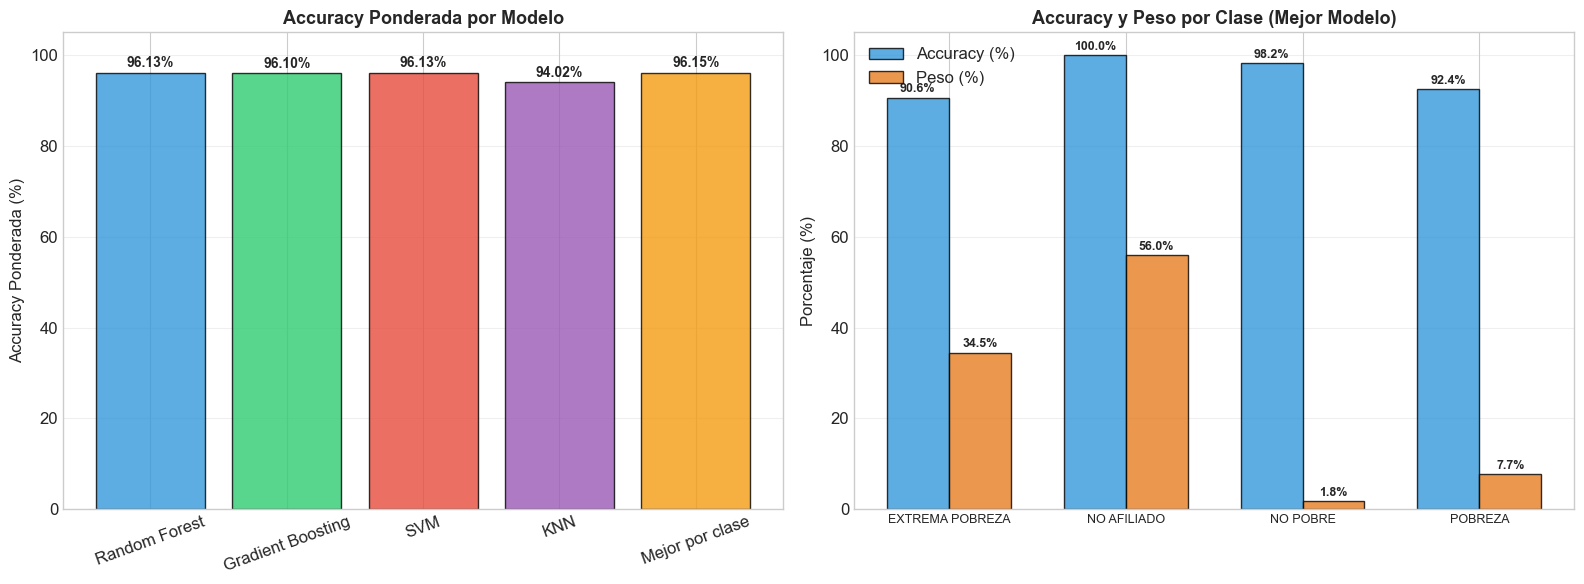

In [33]:
# Visualización de la accuracy ponderada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Accuracy ponderada por modelo
modelos_plot = list(accuracies_ponderadas_por_modelo.keys()) + ['Mejor por clase']
acc_plot = list(accuracies_ponderadas_por_modelo.values()) + [accuracy_ponderada]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

bars = axes[0].bar(modelos_plot, [a*100 for a in acc_plot], color=colors_bar, 
                   edgecolor='black', alpha=0.8)
for bar, val in zip(bars, acc_plot):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_title('Accuracy Ponderada por Modelo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy Ponderada (%)')
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=20)

# Gráfico 2: Desglose de accuracy por clase (mejor modelo)
acc_clases = [mejor_modelo_por_clase[c]['resultado']['accuracy']*100 for c in clases]
peso_clases = [pesos[c]*100 for c in clases]
labels_clases = [c[:15] for c in clases]

x = np.arange(len(clases))
width = 0.35

bars1 = axes[1].bar(x - width/2, acc_clases, width, label='Accuracy (%)', 
                    color='#3498db', edgecolor='black', alpha=0.8)
bars2 = axes[1].bar(x + width/2, peso_clases, width, label='Peso (%)', 
                    color='#e67e22', edgecolor='black', alpha=0.8)

for bar, val in zip(bars1, acc_clases):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, peso_clases):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_title('Accuracy y Peso por Clase (Mejor Modelo)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_clases, fontsize=9)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 4.1 Importancia de Características

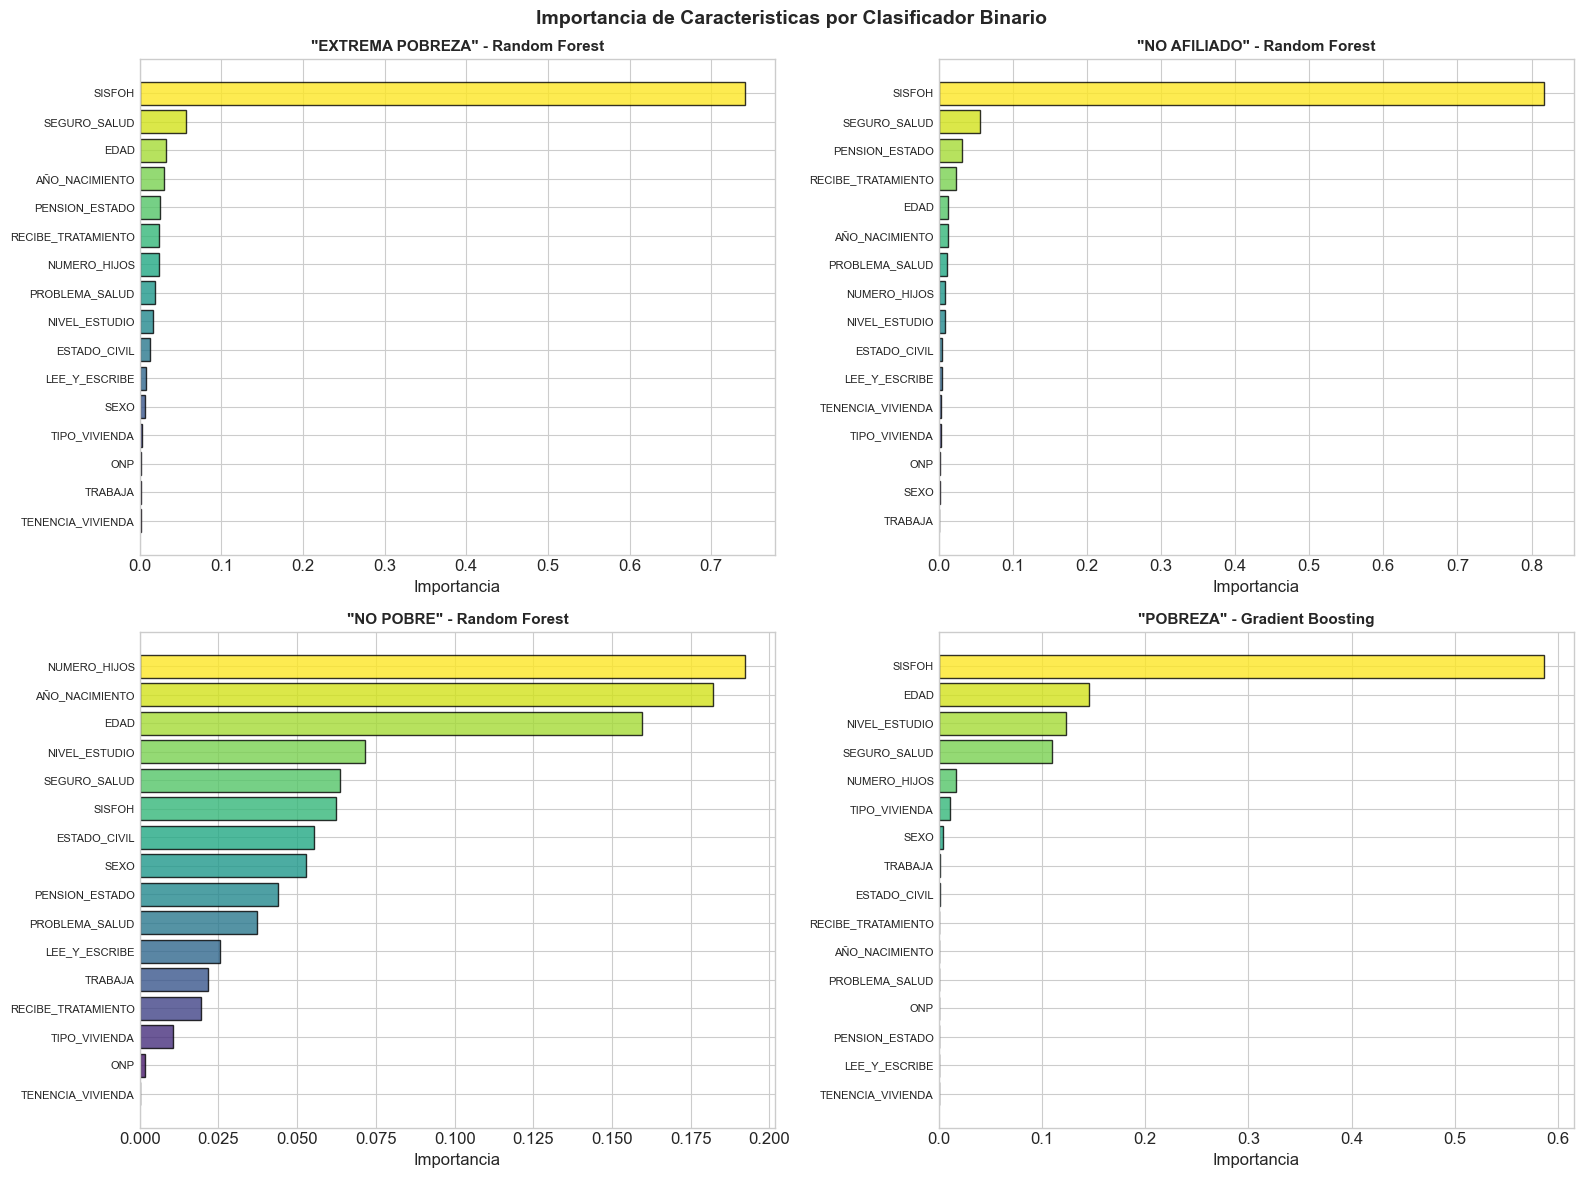

In [34]:
# Importancia de características para cada clasificador binario (si es basado en árboles)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, clase in enumerate(clases):
    mejor = mejor_modelo_por_clase[clase]
    mejor_est = mejor['resultado']['grid'].best_estimator_
    
    if hasattr(mejor_est, 'feature_importances_'):
        importancias = mejor_est.feature_importances_
        indices = np.argsort(importancias)[::-1]
        
        axes[idx].barh(range(len(features)), importancias[indices[::-1]],
                       color=plt.cm.viridis(np.linspace(0, 1, len(features))),
                       edgecolor='black', alpha=0.8)
        axes[idx].set_yticks(range(len(features)))
        axes[idx].set_yticklabels([features[i] for i in indices[::-1]], fontsize=8)
        axes[idx].set_title(f'"{clase}" - {mejor["nombre"]}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Importancia')
    else:
        axes[idx].text(0.5, 0.5, f'{mejor["nombre"]}\nNo soporta\nfeature importance', 
                      ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
        axes[idx].set_title(f'"{clase}"', fontsize=11, fontweight='bold')

plt.suptitle('Importancia de Caracteristicas por Clasificador Binario', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Conclusiones

In [35]:
# Resumen final
print('='*70)
print('RESUMEN FINAL DE LA PRACTICA DE CLASIFICACION')
print('='*70)

print(f'\nDataset: Beneficiarios del CIAM - La Arena')
print(f'Variable objetivo: NIVEL_POBREZA ({len(clases)} clases)')
print(f'Total de muestras utilizadas: {len(df)}')
print(f'Features utilizadas: {len(features)}')
print(f'Metodologia: Clasificador binario por cada clase (One-vs-Rest)')

print(f'\n--- Mejor clasificador binario por clase ---\n')
print(f'{"Clase":<25} {"Modelo":<25} {"ACCURACY":<12} {"PRECISION":<12} {"RECALL":<12} {"F1-SCORE":<12}')
print('-' * 98)

for clase in clases:
    mejor = mejor_modelo_por_clase[clase]
    r = mejor['resultado']
    print(f'{clase:<25} {mejor["nombre"]:<25} {r["accuracy"]*100:<12.2f} {r["precision"]*100:<12.2f} {r["recall"]*100:<12.2f} {r["f1"]*100:<12.2f}')

print(f'\n{"="*50}')
print(f'  ACCURACY PONDERADA FINAL = {accuracy_ponderada*100:.2f}%')
print(f'{"="*50}')

# Evaluación según rúbrica
acc_final = accuracy_ponderada * 100
if acc_final >= 90:
    nota = 20
    print(f'\nEvaluacion: Resultado >= 90% --> Nota: {nota}/20')
elif acc_final >= 80:
    nota = 16
    print(f'\nEvaluacion: Resultado >= 80% --> Nota: {nota}/20')
elif acc_final >= 50:
    nota = 12
    print(f'\nEvaluacion: Resultado >= 50% --> Nota: {nota}/20')
else:
    nota = 0
    print(f'\nEvaluacion: Resultado < 50%')

print(f'\n--- Accuracy ponderada por modelo (referencia) ---')
for nombre, acc in sorted(accuracies_ponderadas_por_modelo.items(), key=lambda x: x[1], reverse=True):
    print(f'  {nombre:<25} {acc*100:.2f}%')
print(f'  {"Mejor por clase (mixto)":<25} {accuracy_ponderada*100:.2f}%')

RESUMEN FINAL DE LA PRACTICA DE CLASIFICACION

Dataset: Beneficiarios del CIAM - La Arena
Variable objetivo: NIVEL_POBREZA (4 clases)
Total de muestras utilizadas: 3100
Features utilizadas: 16
Metodologia: Clasificador binario por cada clase (One-vs-Rest)

--- Mejor clasificador binario por clase ---

Clase                     Modelo                    ACCURACY     PRECISION    RECALL       F1-SCORE    
--------------------------------------------------------------------------------------------------
EXTREMA POBREZA           Random Forest             90.65        79.10        99.07        87.97       
NO AFILIADO               Random Forest             100.00       100.00       100.00       100.00      
NO POBRE                  Random Forest             98.23        0.00         0.00         0.00        
POBREZA                   Gradient Boosting         92.42        100.00       2.08         4.08        

  ACCURACY PONDERADA FINAL = 96.15%

Evaluacion: Resultado >= 90% --> Nota: 2